# <center>Recherche Opérationnelle<br /> Workshop</center>

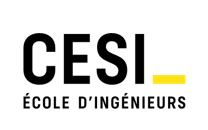

Ce Workshop aborde l'une des méthodes de résolution les plus utilisées dans la Recherche Opérationnelle, la Programmation Linéaire. Nous allons nous concentrer sur la modélisation par programmation linéaire, ses différentes variantes, et différentes méthodes de résolutions avec leurs limites.

Vous aurez un certain nombre d'équations à écrire. Rappel&nbsp;: vous pouvez insérer dans une cellule Markdown des [équations au format $\mathrm{\LaTeX}$](https://www.math.ubc.ca/~pwalls/math-python/jupyter/latex/) en les plaçant entre \\$. Par exemple, le code<br />
```latex
$$\sum_{i=1}^n n$$
 ```
 
produira l'expression mathématique<br />
$$\sum_{i=1}^n n$$

# 1. Programme linéaire en nombre réels à 2 dimensions

## Exercice 1 : Fabrication de Yaourts

<div style="display: flex; align-items: flex-start;">

<div style="flex: 4; padding-right: 30px;">
Un fabricant de yaourt produit 2 types de yaourts 𝐴 et 𝐵 à partir de fraises, de lait et de sucre.

Pour fabriquer 𝐴, il faut :
* 2kg de fraises,
* 1kg de lait.

Pour fabriquer 𝐵, il faut :
* 1kg de fraises,
* 2kg de lait 
* 1kg de sucre.

Les matières premières sont en quantité limitée : 8Kg de fraises, 7Kg de lait et 3Kg de sucre.  
La vente du yaourt 𝐴 rapporte 4€ par Kg, tandis que la vente du yaourt 𝐵 rapporte 5€ par Kg.

Combien faut-il fabriquer de produits A et B, pour avoir le maximum de bénéfice ?
</div>
<div style="flex: 1; margin-left: 20px;">
    <img src="images/yaourt.jpg" width="250">
</div>

</div>

## 1.1 Modélisation du problème 


Commençons par modéliser le problème sous la forme d'un programme linéaire.

Lorsque l’on aborde un problème de programmation linéaire, il est impératif de bien cerner ses trois composantes essentielles : les variables de décision, les contraintes et l’objectif.   

Les bonnes questions à se poser !

Question 1 : Dans un problème de programmation linéaire, que représentent les variables de décision ?

1. Les limites imposées par le problème ? 
2. Le but à atteindre ? 
3. Les éléments que l'on peut contrôler ou ajuster pour atteindre l'objectif ? 
4. Les données fixées du problèmes ? 

In [16]:
Q1 = 3

Question 2 : Que représente la fonction objectif dans un programme linéaire ?
1. Les conditions que la solution doit respecter
2. Le but à atteindre, comme un coût à minimiser ou un profit à maximiser
3. L'ensemble des variables que l'on peut modifier
4. Le nombre de solutions possibles

In [17]:
Q2 = 2

Question 3 : À quoi servent les contraintes dans un programme linéaire ?

1. À définir l'objectif du problème
2. À identifier les variables de décision
3. À délimiter les conditions que les solutions doivent respecter
4. À calculer la valeur optimale de la fonction objectif

In [18]:
Q3 = 3

### 1.1.1 Variables de décision du programme
Identifiez les inconnues qui sont à déterminer dans le problème. On les nommera avec des variables $X_1$, $X_2$,…

* $X_1$ : Quantité (en kg) de yaourts A à fabriquer.
* $X_2$ : Quantité (en kg) de yaourts B à fabriquer.

### 1.1.2 Contraintes du programme
Quelles contraintes identifiez-vous dans le texte&nbsp;?

Les matières premières sont limitées : 8kg de fraises, 7kg de lait et 3kg de sucre. De plus, les quantités produites ne peuvent pas être négatives.

Modélisez toutes ces contraintes sous formes d'inéquations sur une ou plusieurs variables de notre problème.

* Fraises : $2 X_1 + X_2 \leq 8$
* Lait : $X_1 + 2 X_2 \leq 7$
* Sucre : $X_2 \leq 3$
* Non-négativité : $X_1 \geq 0$ et $X_2 \geq 0$

###  1.1.3 Fonction économique
Exprimez la fonction économique du problème.

L'objectif est de maximiser le bénéfice obtenu par la vente des yaourts. La vente d'un kilogramme de yaourt A rapporte 4€ et celle de B rapporte 5€.
La fonction économique est donc : $\text{Maximiser } Z = 4X_1 + 5X_2$

###  1.1.4 Programme linéaire complet
Réunissez les réponses du dessus pour exprimer le programme linéaire complet optimisant la composition des bonbons de l'usine. Vous pouvez compléter la formule $\mathrm{\LaTeX}$ ci-dessous ($\text{s.c.}$ veut dire _sous contraintes_)&nbsp;:

$
\begin{array}{ll}
\text{Maximiser} & Z = 4X_1 + 5X_2 \\
\text{s.c.} & 2X_1 + X_2 \leq 8 \\
            & X_1 + 2X_2 \leq 7 \\
            & X_2 \leq 3 \\
            & X_1 \geq 0 \\
            & X_2 \geq 0
\end{array}
$

## 1.2 Résolution par la méthode graphique

Pour comprendre le comportement de ce genre de système, on va regarder comment il se comporte graphiquement. Chaque variable sera représentée sur un axe du graphique. Ici, le problème a deux variables, il sera représenté sur un plan. Nous allons prendre la convention suivante&nbsp;: $X_1$ sera représenté sur l'axe des abscisses et $X_2$ sera représenté sur l'axe des ordonnées.


Nous allons représenter sur ce plain les inéquations de contraintes et la fonction économique. Pour cela, nous utiliserons [matplotlib](https://matplotlib.org/3.1.0/tutorials/introductory/pyplot.html).

### 1.2.1 Représentation des contraintes
Commençons par placer les différentes contraintes

Déjà, comment tracer une droite en Python&nbsp;? C'est très simple avec [la fonction `plot`](https://matplotlib.org/3.1.0/tutorials/introductory/pyplot.html) de la bibliothèque [Matplotlib](https://matplotlib.org/3.1.0/tutorials/), surtout si on utilise [NumPy](https://www.courspython.com/apprendre-numpy.html) pour manipuler des [intervalles de valeurs linéaires](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linspace.html). Il suffit d'utiliser la fonction [`fill_between`](https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.fill_between.html).


Avant de l'utiliser pour afficher notre programme linéaire, testons ça sur un petit exemple. Mettons qu'on veuille représenter l'inéquation $2x_1 + x_2 \leq 4$



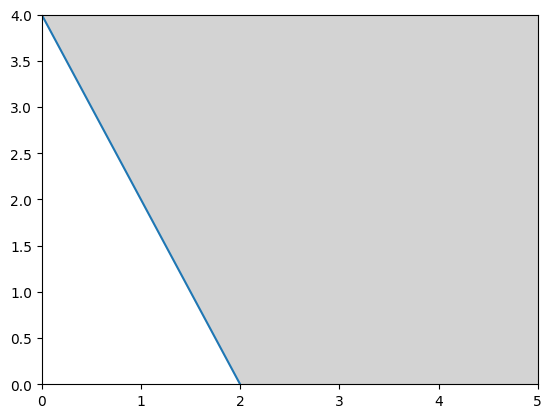

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x1_max = 5
x1 = np.linspace(0, x1_max) # on genere l'intervalle des x
x2 = 4 - 2 * x1 # on genere l'intervalle des y

x2_max = np.amax(x2)

plt.plot(x1, x2)
plt.fill_between(x1, x2, x2_max, color='lightgrey')

# on dessine entre 0,0 et les extremas des fonctions
plt.xlim(0, x1_max)
plt.ylim(0, x2_max)

# on affiche
plt.show()

On a donc tout ce qu'il nous faut pour afficher les inéquations de nos contraintes. Traçons les droites en rouge, et les zones d'inégalités en gris.



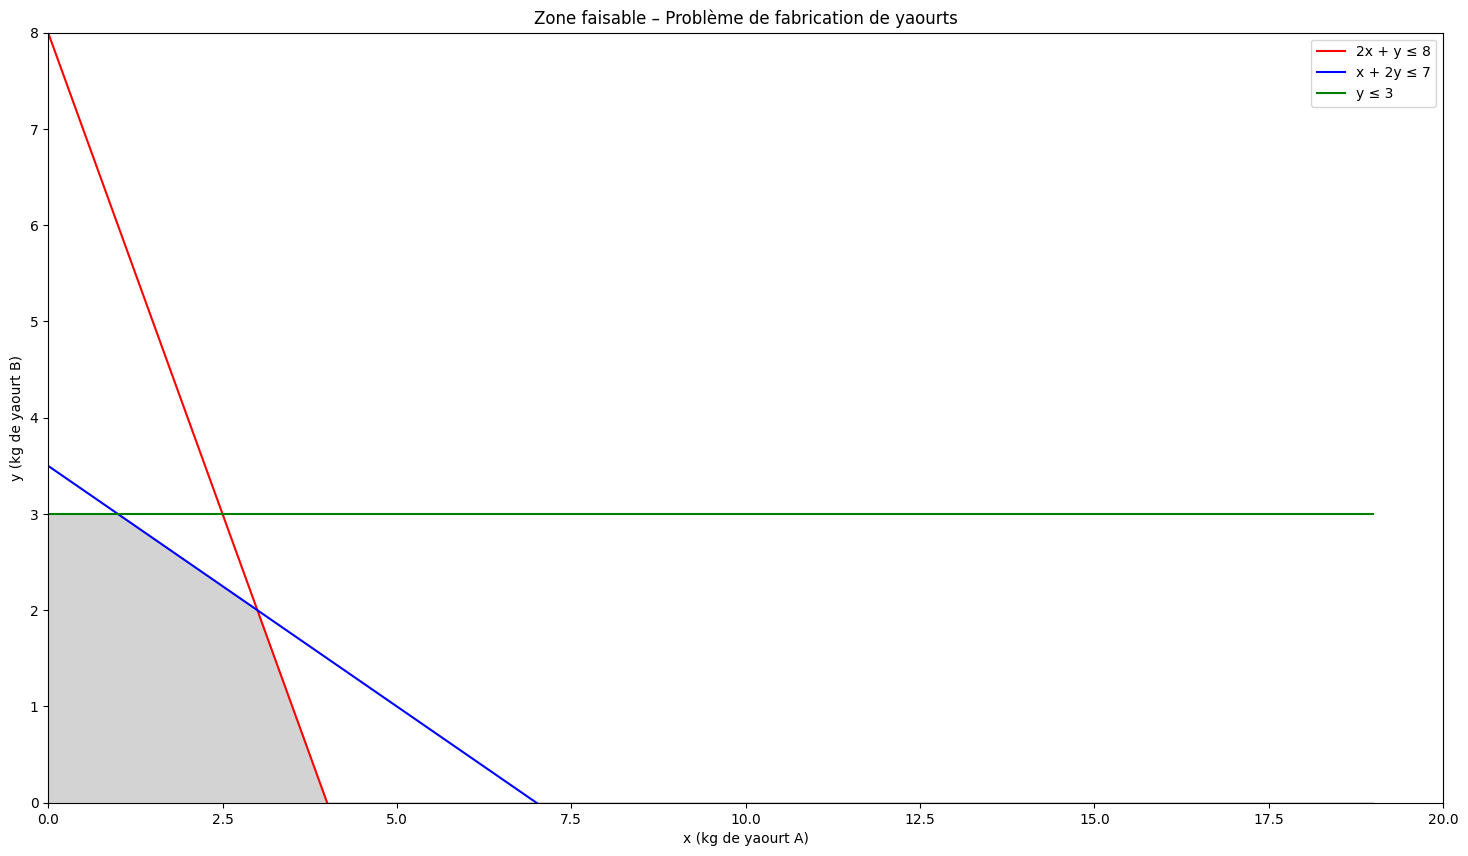

In [20]:
import numpy as np
import matplotlib.pyplot as plt

xmax = 20
x1 = np.arange(0, xmax)

# Contraintes
y1 = 8 - 2 * x1
y2 = (7 - x1) / 2
y3 = np.full_like(x1, 3.0)  # ligne horizontale y = 3

# Valeur maximale utile du graphe
ymax = max(np.max(y1), np.max(y2), np.max(y3))

# Tracé des contraintes
plt.plot(x1, y1, label="2x + y ≤ 8", color='red')
plt.plot(x1, y2, label="x + 2y ≤ 7", color='blue')
plt.plot(x1, y3, label="y ≤ 3", color='green')

# Remplissage de la zone faisable (en dessous des trois contraintes)
plt.fill_between(x1, 0, np.minimum(np.minimum(y1, y2), y3), color='lightgrey')

# Axes et limites
plt.ylim(0, ymax)
plt.xlim(0, xmax)

plt.xlabel("x (kg de yaourt A)")
plt.ylabel("y (kg de yaourt B)")
plt.title("Zone faisable – Problème de fabrication de yaourts")

plt.legend()
plt.gcf().set_size_inches(18, 10)
plt.show()

Question 4 : A quoi correspond un point dans le plan ? 
1. Une solution réalisable. 
2. Une solution quelconque. 
3. L'ensemble des solutions optimales. 

In [21]:
Q4 = 2

Question 5 : Que représente la zone grise dans le graphique du programme linéaire ?

1. L'ensemble des solutions optimales uniquement
2. L'espace des solutions admissibles, contenant toutes les valeurs de (X1, X2) respectant les contraintes
3. La zone des solutions interdites
4. La fonction objectif représentée graphiquement

In [22]:
Q5 = 2

Question 5 : Que représente la zone blanche dans le graphique du programme linéaire ?

1. L'ensemble des solutions optimales uniquement
2. L'espace des solutions admissibles, contenant toutes les valeurs de (X1, X2) respectant les contraintes
3. La zone des solutions interdites
4. La fonction objectif représentée graphiquement

In [23]:
Q6 = 3

Question 7 : Quelle est la caractéristique mathématique de cet espace de solutions admissibles ?
1. C'est une surface concave
2. C'est une surface linéaire
3. C'est une surface convexe
4. C'est une surface discontinue

In [24]:
Q7 = 3

Question 8 : Quelle est la forme de l'espace des solutions admissibles ? 
1. Un cercle
2. Une courbe quelconque
3. Un polygone
4. Un triangle rectangle

In [25]:
Q8 = 3

### Représentation de la fonction économique

Nous allons pouvoir utiliser cette propriété pour définir la solution optimale. Il nous faut donc maintenant représenter la fonction économique. Sa forme générale est $ax +by = p$. Cette fonction est la famille des droites correspondant à l’ensemble–solution avec une pente $\dfrac{-a}{b}$. 

Le but est de trouver la fonction linéaire de $p$ qui maximise la fonction économique tout en restant dans l'espace des solutions admissibles. Quelle est la forme générale de cette fonction ? Quelle valeur devons-nous donc déterminer ?

La fonction s'écrit $y = -\frac{a}{b}x + \frac{1}{b}p$. 
Dans notre cas, $Z = 4x + 5y \iff y = -\frac{4}{5}x + \frac{Z}{5}$.
Nous devons déterminer la plus grande valeur de l'ordonnée à l'origine (et donc de la valeur de $Z$) pour laquelle cette droite coupe le polygone des solutions admissibles.

Un [Widget](https://ipywidgets.readthedocs.io/en/stable/examples/Widget%20List.html) intégré [automatiquement](https://ipywidgets.readthedocs.io/en/stable/examples/Using%20Interact.html) à notre fonction de calcul nous permettra de faire varier facilement ce paramètre et de déterminer les valeurs admissibles de $X_1$ et $X_2$ maximisant la fonction économique. Le code vous est fourni, il ne vous reste plus qu'à implémenter le calcul et l'affichage de la fonction économique tenant compte de cette valeur réelle&nbsp;!

Une fois que vous avez localisé globalement la position de la solution, vous pouvez modifier l'intervalle `x` pour zoomer sur cette partie et obtenir un résultat plus précis.

In [ ]:
from ipywidgets import interact
import ipywidgets as widgets

# cette fonction est appelée à chaque changement d'état du slider.
def trace(n):
    # on reprend le code precedent
    xmax = 20
    x1 = np.arange(0, xmax) # on genere l'intervalle des x

    # Contraintes
    y1 = 8 - 2 * x1
    y2 = (7 - x1) / 2
    y3 = np.full_like(x1, 3.0)  # ligne horizontale y = 3

    # Valeur maximale utile du graphe
    ymax = max(np.max(y1), np.max(y2), np.max(y3))

    # Tracé des contraintes
    plt.plot(x1, y1, label="2x + y ≤ 8", color='red')
    plt.plot(x1, y2, label="x + 2y ≤ 7", color='blue')
    plt.plot(x1, y3, label="y ≤ 3", color='green')

    # Remplissage de la zone faisable (en dessous des trois contraintes)
    plt.fill_between(x1, 0, np.minimum(np.minimum(y1, y2), y3), color='lightgrey')

    # Axes et limites
    plt.ylim(0, ymax)
    plt.xlim(0, xmax)

    pente = -4 / 5
    yeco = pente * x1 + n / 5
    plt.plot(x1, yeco, label=f"Z = {n}", linestyle="--", color="purple")
    
    plt.gcf().set_size_inches(18, 10) # cette fois on affiche en grand


    plt.xlabel("x (kg de yaourt A)")
    plt.ylabel("y (kg de yaourt B)")
    plt.title("Zone faisable – Problème de fabrication de yaourts")

    plt.legend()
    plt.gcf().set_size_inches(18, 10)
    plt.show()
    
# le slider qui permet de faire varier la valeur passee en parametre de la fonction trace
interact(trace, n=widgets.FloatSlider(min=-1, max=30.0, step=1, value=0.0));

Question 9 : En utilisant le slider pour déplacer la droite sur le polygone. Que peut-on en déduire sur les valeurs optimale de $X_1$ et $X_2$ ? 

In [ ]:
x1 = 3
x2 = 2

Question 10 : Que vaut la fonction économique ?

In [ ]:
z = 22

Question 11 : Où se trouve la solution optimale d'un programme linéaire ?
1. Au centre de l'espace des solutions admissibles
2. Sur l'un des sommets du polygone convexe
3. Sur n'importe quel point de l'espace admissible
4. Sur le milieu de l'une des arêtes du polygone

In [ ]:
Q11 = 2

# 2. Programme linéaire en nombre réels à $n$ dimensions

Arcelor-Mittal, géant mondial de l'acier, a ouvert une nouvelle usine en Grèce. Il fabrique 9 alliages à base de 3 matières premières&nbsp;: le plomb, le zinc et l'étain.
Voici un tableau avec les pourcentages de chaque matière dans l'alliage et son coût par unité&nbsp;:

| Alliage       | 1   | 2   | 3   | 4   | 5   | 6   | 7   | 8   | 9   |
|---------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|
|**% plomb**    | 20  | 50  | 30  | 30  | 30  | 60  | 40  | 10  | 10  |
|**% zinc**     | 30  | 40  | 20  | 40  | 30  | 30  | 50  | 30  | 10  |
|**% étain**    | 50  | 10  | 50  | 30  | 40  | 10  | 10  | 60  | 80  |
|**Coût unit.** | 7.3 | 6.9 | 7.3 | 7.5 | 7.6 | 6.0 | 5.8 | 4.3 | 4.1 |

Le département de R&D recherche un « nouvel alliage » à prix minimum qui serait un mélange des 9 autres avec les contraintes d'avoir au maximum 30% de plomb, 30% de zinc et 40% d'étain.

## 2.1 Modélisation du problème

Commençons par modéliser le problème sous la forme d'un programme linéaire. Appliquez la méthode de l'exercice précédent.<br />

Variables de décision :
$X_i$ avec $i \in \{1,\dots,9\}$ représentant la proportion de l'alliage $i$ dans le nouveau mélange.

Contraintes :
* Somme des proportions : $\sum_{i=1}^9 X_i = 1$
* Plomb : $20X_1 + 50X_2 + 30X_3 + 30X_4 + 30X_5 + 60X_6 + 40X_7 + 10X_8 + 10X_9 \leq 30$
* Zinc : $30X_1 + 40X_2 + 20X_3 + 40X_4 + 30X_5 + 30X_6 + 50X_7 + 30X_8 + 10X_9 \leq 30$
* Étain : $50X_1 + 10X_2 + 50X_3 + 30X_4 + 40X_5 + 10X_6 + 10X_7 + 60X_8 + 80X_9 \leq 40$
* Positivité : $X_i \geq 0$ pour tout $i$.

Fonction économique :
Minimiser $Z = 7.3X_1 + 6.9X_2 + 7.3X_3 + 7.5X_4 + 7.6X_5 + 6.0X_6 + 5.8X_7 + 4.3X_8 + 4.1X_9$

## 2.2 Résolution
Nous sommes en présence d'un problème à 9 variables. La méthode de résolution graphique ne peut pas être appliquée ici, nous allons nous tourner vers le solveur [PuLP](https://pythonhosted.org/PuLP/) qui calculera lui-même la solution, en exploitant la propriété qu'on a identifiée dans l'exercice précédent.


On va s'inspirer d'[un exemple basique](https://www.coin-or.org/PuLP/CaseStudies/a_blending_problem.html) pour implémenter et résoudre le modèle&nbsp;:



In [ ]:
from pulp import *
import numpy as np

# variables du problème
X1 = LpVariable("X_1", 0, None)
X2 = LpVariable("X_2", 0, None)
X3 = LpVariable("X_3", 0, None)
X4 = LpVariable("X_4", 0, None)
X5 = LpVariable("X_5", 0, None)
X6 = LpVariable("X_6", 0, None)
X7 = LpVariable("X_7", 0, None)
X8 = LpVariable("X_8", 0, None)
X9 = LpVariable("X_9", 0, None)


# probleme
prob = LpProblem("alliage", LpMinimize)

# objectif
prob += 7.3*X1 + 6.9*X2 + 7.3*X3 + 7.5*X4 + 7.6*X5 + 6.0*X6 + 5.8*X7 + 4.3*X8 + 4.1*X9

# contraintes
prob += X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9 == 1
prob += 20*X1 + 50*X2 + 30*X3 + 30*X4 + 30*X5 + 60*X6 + 40*X7 + 10*X8 + 10*X9 <= 30
prob += 30*X1 + 40*X2 + 20*X3 + 40*X4 + 30*X5 + 30*X6 + 50*X7 + 30*X8 + 10*X9 <= 30
prob += 50*X1 + 10*X2 + 50*X3 + 30*X4 + 40*X5 + 10*X6 + 10*X7 + 60*X8 + 80*X9 <= 40

prob.solve()
print(LpStatus[prob.status])
print("Min=", value(prob.objective))

# variables resultat
for v in prob.variables():
    print("%s=%.2f"%(v.name,v.varValue), end=', ')


Nous avons notre solution optimale&nbsp;! On peut même pousser le raffinement jusqu'à utiliser $\mathrm{\LaTeX}$ pour améliorer le rendu&nbsp;:

In [ ]:
from IPython.display import display, Latex

# variables resultat
result = ""
for v in prob.variables():
    valeur = round(v.varValue*100, 2)
    if valeur > 0:
        result += "$"+v.name+"="+str(valeur)+"\%$, "

display(Latex(result))

Une remarque&nbsp;: PuLP accepte aussi bien des problèmes de minimisation que de maximisation, et des contraintes d'infériorité que de supériorité. Mais tous les solveurs ne sont pas aussi souples, certains n'acceptent que programmes linéaires sous forme canonique pure, d'autres sous forme standard. Pourquoi&nbsp;? À votre avis, comment PuLP peut-il faire pour s'interfacer avec ces solveurs solveurs&nbsp;? 

PuLP transforme automatiquement le modèle sous la forme attendue par le solveur appelé. Il introduit des variables d'écart (slack variables) ou d'excédent pour transformer des inéquations en équations (standardisation), il peut multiplier des contraintes et la fonction objectif par -1 pour remplacer une maximisation par une minimisation ou inverser le sens des inéquations.

Par ailleurs, l'algorithme du Simplexe n'est pas le seul sachant résoudre un programme linéaire. PuLP peut en utiliser un autre. Le connaissez-vous&nbsp;? Quels sont leurs principes généraux de fonctionnement, et leurs performances&nbsp;?

Oui, l'algorithme des points intérieurs (comme la méthode de Karmarkar) est souvent utilisé. 
- *Le Simplexe* explore les sommets du polyèdre (sur la frontière) jusqu'à trouver l'optimum. En pratique il est très rapide bien que sa complexité dans le pire des cas soit exponentielle.
- *Les méthodes de points intérieurs* traversent l'intérieur du domaine réalisable (le polyèdre) plutôt que de suivre sa frontière. Elles ont une complexité polynomiale, et sont très performantes sur des problèmes de très grande taille.

# 3. Programmation linéaire en nombres entiers

Un étudiant possède une bibliothèque musicale contenant 10 titres (certes, c'est peu, et il n'a même pas de compte sur un service de streaming, préférant gérer sa musique localement). Le logiciel qu'il utilise pour gérer sa bibliothèque lui permet de donner une note dans un intervalle de 1 à 5 étoiles à chaque titre, 5 étant la meilleure note. Notre étudiant a un très bon goût musical, et il écoute d'ailleurs sa musique dans un format Lossless, ce qui explique la taille des fichiers. Mais son smartphone est saturé par les milliers de photos, et les jeux inutiles, et sa capacité résiduelle pour stocker la musique est de 500Mo&nbsp;:<br />
<br />

<div style="float:left;"><table>
  <tr><th style="text-align:left">Titre</th><th style="text-align:left">Note</th><th>Poids (Mo)</th></tr>
  <tr>
      <td style="text-align:left">Led Zeppelin - Whole Lotta Love</td> <td style="text-align:left">☆☆</td> <td>40</td></tr>
  <tr><td style="text-align:left">Magma - Retrovision (je suis revenu de l'univers)</td> <td style="text-align:left">☆☆☆☆☆</td> <td>52</td></tr>
  <tr><td style="text-align:left">The Manhattan Project - Goodbye Pork Pie Hat (live)</td> <td style="text-align:left">☆</td> <td>27</td></tr>
  <tr><td style="text-align:left">Jaco Pastorius - The Chicken (live)</td> <td style="text-align:left">☆☆</td> <td>68</td></tr>
  <tr><td style="text-align:left">Steve Ray Vaughan - Little Wing</td> <td style="text-align:left">☆☆☆</td> <td>80</td></tr>
  <tr><td style="text-align:left">Lynyrd SKynyrd - Free Bird (live)</td> <td style="text-align:left">☆☆☆☆☆</td> <td>62</td></tr>
  <tr><td style="text-align:left">Genesis - Back In NYC</td> <td style="text-align:left">☆☆</td> <td>63</td></tr>
  <tr><td style="text-align:left">The Who - I Can See For Miles</td> <td style="text-align:left">☆☆☆</td> <td>53</td></tr>
  <tr><td style="text-align:left">Jean-Luc Ponty - Jig (live)</td> <td style="text-align:left">☆</td> <td>56</td></tr>
  <tr><td style="text-align:left">David Bowie - Space Oddity</td> <td style="text-align:left">☆</td> <td>59</td></tr>
</table></div>

![Smartphone.png]( 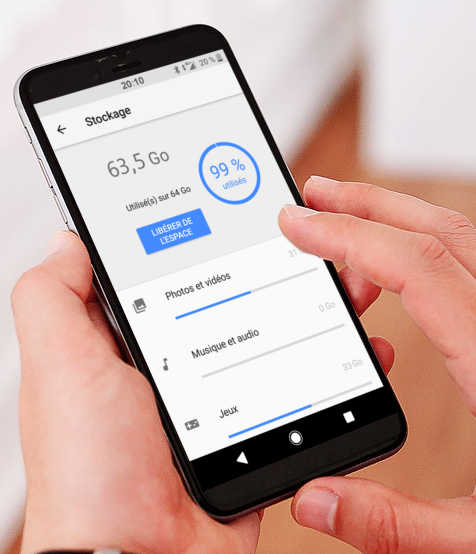)


Question 12 : Il souhaite remplir son smartphone de manière à avoir la meilleure liste de lecture possible à partir de sa bibliothèque, c'est à dire que la somme des notes des titres choisis doit être maximale. À quel problème problème connu cela vous fait-il penser ?
1. Le problème du voyageur de commerce
2. Le problème du sac à dos (Knapsack Problem)
3. Le problème de coloration de graphe
4. Le problème d'ordonnancement

In [ ]:
Q12 = 2

Question 13 : Dans le problème du sac à dos, quel est l'objectif ?

1. Minimiser le nombre d'objets dans le sac
2. Maximiser l'encombrement total des objets choisis
3. Trouver un sous-ensemble d'objets dont la valeur totale est maximale sans dépasser la capacité du sac
4. Minimiser la valeur totale des objets laissés de côté

In [ ]:
Q13 = 3

## 3.1 Modélisation du problème
Comment pouvons nous modéliser ce problème sous la forme d'un programme linéaire&nbsp;?

Variables de décision :
$X_i \in \{0, 1\}$ pour $i \in \{1,\dots,10\}$ où $X_i = 1$ si la piste $i$ est sélectionnée pour être sur le téléphone, $0$ sinon.

Contrainte de capacité :
$40X_1 + 52X_2 + 27X_3 + 68X_4 + 80X_5 + 62X_6 + 63X_7 + 53X_8 + 56X_9 + 59X_{10} \leq 500$

Fonction économique :
Maximiser $Z = 2X_1 + 5X_2 + 1X_3 + 2X_4 + 3X_5 + 5X_6 + 2X_7 + 3X_8 + 1X_9 + 1X_{10}$


<br />

Un algorithme naïf pour déterminer un résultat optimal serait une approche par force brute, qui teste toutes les solutions (admissibles ou non) et conserve la meilleure solution admissible. Dans le cas de notre étudiant, c'est une solution qui semble envisageable. Mais si l'étudiant supprime plusieurs Giga octets de jeux, et qu'il enrichit sa bibliothèque musicale, cette solution restera-t-elle viable&nbsp;? Qu'est-ce qui va devenir bloquant&nbsp;?

Si le nombre de pistes $n$ augmente, le nombre total de combinaisons possibles est $2^n$. L'algorithme naïf a donc une complexité temporelle exponentielle $O(2^n)$, ce qui entraînera une explosion combinatoire ("mur de la complexité"). Le temps de calcul deviendra bloquant bien avant que la capacité de stockage ne le soit.

## 3.2 Résolution

Puisque nous avons modélisé le problème sous forme linéaire, pourquoi ne pas tester l'algorithme du Simplexe dessus&nbsp;? Reprenons les données issues du Smartphone de notre étudiant. Attention aux bornes de nos variables&nbsp;!

In [ ]:
# variables du problème
X1  = LpVariable("X_01", 0, 1)
X2  = LpVariable("X_02", 0, 1)
X3  = LpVariable("X_03", 0, 1)
X4  = LpVariable("X_04", 0, 1)
X5  = LpVariable("X_05", 0, 1)
X6  = LpVariable("X_06", 0, 1)
X7  = LpVariable("X_07", 0, 1)
X8  = LpVariable("X_08", 0, 1)
X9  = LpVariable("X_09", 0, 1)
X10 = LpVariable("X_10", 0, 1)


# probleme
prob = LpProblem("knapsack", LpMaximize)

# objectif
prob += 2*X1 + 5*X2 + 1*X3 + 2*X4 + 3*X5 + 5*X6 + 2*X7 + 3*X8 + 1*X9 + 1*X10

# contrainte
prob += 40*X1 + 52*X2 + 27*X3 + 68*X4 + 80*X5 + 62*X6 + 63*X7 + 53*X8 + 56*X9 + 59*X10 <= 500

prob.solve()
print(LpStatus[prob.status])
print("Valeur totale = ", value(prob.objective))

poids_total = 0.0
poids = [40, 52, 27, 68, 80, 62, 63, 53, 56, 59]
for idx, v in enumerate(prob.variables()):
    print("X%d=%d" % (idx+1, v.varValue), end=', ')
    poids_total += int(v.varValue)*poids[idx]
print("\npoids=%d" % poids_total)

Ça vous parait correct&nbsp;? Pourtant, cela ne l'est pas&nbsp;! Calculez à la main le poids de la solution, en reprenant les valeurs dans le tableau. Qu'obtenez-vous&nbsp;? Pourquoi&nbsp;?

Le poids calculé à la main avec les vraies valeurs peut dépasser la contrainte ou omettre une partie car la composante `int(v.varValue)` a tronqué une variable continue qui avait une valeur non entière (fractionnaire) comprise entre $0$ et $1$ exclusive. Étant donné qu'on a déclaré les variables comme réelles (continues) comprises entre $0$ et $1$, la solution obtenue n'est pas une simple solution en nombres entiers de `0` ou `1`. C'est la relaxation continue du SAC À DOS (valeur fractionnaire acceptée).

Vérifions ça&nbsp;:

In [ ]:
poids_total=0.0
for idx, v in enumerate(prob.variables()):
    print("X%d=%f" % (idx+1, v.varValue), end=', ')
    poids_total += v.varValue*poids[idx]
print("\npoids=%d"%poids_total)

Et là ça ne va plus du tout, La solution n'est pas admissible. On a vu qu'un arrondi inférieur produisait une solution qui, elle, est admissible. Mais avec une valeur de $X_9$ aussi proche de 1, ce n'est peut-être pas la solution optimale. Est-ce qu'un <a href="https://www.w3schools.com/python/ref_func_round.asp">arrondi au plus proche</a> marcherait mieux&nbsp;?

In [ ]:
poids_total=0.0
for idx, v in enumerate(prob.variables()):
    print("X%d=%f" % (idx+1, v.varValue), end=', ')
    poids_total += int(round(v.varValue))*poids[idx]
print("\npoids=%d" % poids_total)

Qu'observe-t-on&nbsp;?

On observe que lorsque l'on arrondit certaines valeurs fractionnaires, le poids total dépasse souvent la limite stricte de $500\text{ Mo}$ (solution hors espace admissible) ou que l'on perd une partie de la valeur optimale si l'arrondi se fait en omettant des titres profitables. La tentative de relaxation continue, puis d'arrondissement heuristique, ne garantit en aucun cas une solution exacte au problème PLNE (Programmation Linéaire en Nombres Entiers).

Parmi toutes les solutions générées, nous en avons une solution qui est admissible. Est-ce une bonne méthode pour trouver une solution optimale&nbsp;? Prenons cet exemple, dans lequel l'espace des solutions admissibles délimité par les deux contraintes est en blanc. Est-ce que, pour un problème _de maximisation_, arrondir une solution optimale réelle fonctionnerait&nbsp;?

Dans un problème de PLNE (*Integer Programming*), la simple opération d’arrondi sur l'optimum relaxé (le point continu idéal trouvé au sommet d'un polyèdre) n'est absolument pas garantie de donner l'optimum discret. En effet : la solution arrondie peut tomber sur un point qui n'est pas réalisable (qui brise une contrainte), ou peut se trouver loin de la solution entière réellement optimale qui pourrait être sur un tout autre point du polyèdre intérieur.   

C'est finalement assez logique, puisque le problème de décision est $\mathcal{NP}$-Complet ([on le sait depuis 1972](https://fr.wikipedia.org/wiki/21_probl%C3%A8mes_NP-complets_de_Karp)). Le nombre exponentiel de solution, qu'on a démontré tout à l'heure, était-il un indice&nbsp;?

Oui ! Dans les méthodes exhaustives (comme l'approche de force brute pour vérifier si le sac ne dépasse pas sans louper une meilleure solution potentielle), le temps d'exécution augmente de manière exponentielle : le problème est donc intraitable en pratique de manière exacte au fur et à mesure que la taille $N$ du problème croît, et pour trouver de vraies solutions entières, il faut soit des heuristiques d'exploration (Branch-and-Bound, plans sécants), ou d'implémenter l'algorithme "Programmation Dynamique" exact qui résout le problème du Knapsack par "sous-structure optimale".


# 4 Conclusion

Ce Workshop est maintenant fini, vous avez utilisé la programmation linéaire, vous en avez découvert les principes mathématiques de base, le fonctionnement général, et vous en avez testé les limites.


Et si vous êtes déçus de ne pas être venus à bout du problème du sac à dos, rassurez-vous, on ne s'avoue pas vaincus, dès la semaine prochaine, on s'y attaque à nouveau. Et cette fois-ci, avec beaucoup plus de succès&nbsp;!